# Visualize DLC results 

## Import recording

Load packages

In [1]:
##### LOCAL or INTERACTIVE NODES #####

from ipyfilechooser import FileChooser
import ipywidgets as widgets
import matplotlib.path as mpath
import matplotlib.patches as mpatches

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import os
from pathlib import Path
import re
from scipy.ndimage import median_filter
from scipy.interpolate import interp1d
from scipy.spatial import distance

from scipy.ndimage import gaussian_filter
from scipy.ndimage import gaussian_filter1d

Define functions

In [2]:
def calculate_relative_distance(x1, y1, x2, y2):
    return math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

def calculate_distance_run(x_coords, y_coords):
    distances = np.sqrt(np.diff(x_coords) ** 2 + np.diff(y_coords) ** 2)
    for i in range(1, len(distances) - 1):
        if np.isnan(distances[i]):
            neighbors = [distances[i-1], distances[i+1]]
            distances[i] = np.mean([x for x in neighbors if not np.isnan(x)])
    total_distance_cm = np.nansum(distances) / pixel_to_cm  # Convert to cm
    return total_distance_cm, distances

def find_long_non_nan_sequences(arr, min_length=5):
    mask = ~np.isnan(arr)  # True for non-NaN values
    diff = np.diff(np.concatenate(([0], mask.astype(int), [0])))  # Add padding to detect edges
    starts = np.where(diff == 1)[0]  # Where a sequence starts
    ends = np.where(diff == -1)[0]   # Where a sequence ends
    sequences = [arr[start:end] for start, end in zip(starts, ends) if (end - start) > min_length]
    return sequences

def remove_outliers_median_filter(data, window=4):
    data = np.array(data, dtype=float)  # Ensure NumPy array with float type
    filtered_data = np.copy(data)  # Copy to avoid modifying original data
    half_window = window // 2
    for i in range(len(data)):
        # Define window range, ensuring it doesn't exceed bounds
        start = max(0, i - half_window)
        end = min(len(data), i + half_window + 1)
        # Extract local values in window
        local_values = data[start:end]
        # Check if the window contains at least one non-NaN value
        if np.all(np.isnan(local_values)):
            median_value = np.nan  # Keep NaN if no valid numbers
        else:
            median_value = np.nanmedian(local_values)  # Compute median ignoring NaNs
        # Replace only if the current value is not NaN
        if not np.isnan(data[i]):
            filtered_data[i] = median_value
    return filtered_data

def replace_high_speed_points_with_nan(x, y, speed_threshold):
    x = np.array(x, dtype='float')
    y = np.array(y, dtype='float')
    # Compute speed between consecutive points
    dx = np.diff(x)
    dy = np.diff(y)
    speeds = np.sqrt(dx**2 + dy**2)
    # Create mask for speed exceeding threshold
    high_speed_mask = speeds > speed_threshold
    # We mark i+1 as NaN if speed between them is too high
    x_out = x.copy()
    y_out = y.copy()
    for i in range(len(high_speed_mask)):
        if high_speed_mask[i]:
            # Only mark the faster of the two points
            if i > 0 and i < len(x) - 1:
                if speeds[i] > speeds[i - 1]:
                    x_out[i + 1] = np.nan
                    y_out[i + 1] = np.nan
                else:
                    x_out[i] = np.nan
                    y_out[i] = np.nan
    return x_out, y_out

def interpolate_2d_path(x, y, kind='linear', fill='extrapolate'):
    x = np.array(x, dtype='float')
    y = np.array(y, dtype='float')
    indices = np.arange(len(x))
    valid_mask = ~np.isnan(x) & ~np.isnan(y)
    if np.sum(valid_mask) < 2:
        raise ValueError("Not enough valid points to interpolate/extrapolate.")
    interp_x = interp1d(indices[valid_mask], x[valid_mask], kind=kind, fill_value=fill, bounds_error=False)
    interp_y = interp1d(indices[valid_mask], y[valid_mask], kind=kind, fill_value=fill, bounds_error=False)
    x_filled = x.copy()
    y_filled = y.copy()
    nan_mask = np.isnan(x) | np.isnan(y)
    x_filled[nan_mask] = interp_x(indices[nan_mask])
    y_filled[nan_mask] = interp_y(indices[nan_mask])
    return x_filled, y_filled

def limit_speed(x, y, max_speed):
    dx = np.diff(x.copy())
    dy = np.diff(y.copy())
    speeds = np.sqrt(dx**2 + dy**2)
    for i,t in enumerate(speeds):
        if t > max_speed:        
            x[i+1] = x[i] 
            y[i+1] = y[i] 
            x[i+2] = x[i] 
            y[i+2] = y[i] 
    return x, y

def remove_short_sequences(arr, max_len=10):
    arr = np.array(arr, dtype='float')
    result = arr.copy()
    is_value = ~np.isnan(arr)
    i = 0
    while i < len(arr):
        if is_value[i]:
            start = i
            while i < len(arr) and is_value[i]:
                i += 1
            end = i
            seq_len = end - start
            # Check if surrounded by NaNs and short enough
            if seq_len <= max_len:
                left_nan = (start == 0) or np.isnan(arr[start - 1])
                right_nan = (end == len(arr)) or np.isnan(arr[end])  # safe for edge
                if left_nan and right_nan:
                    result[start:end] = np.nan
        else:
            i += 1
    return result

Load .h5 file

In [3]:
#filename = "/mnt/data/Noemie_dlc/Training D4/A2_3837_TD4_5DLC_Resnet50_CheeseboardFeb6shuffle1_snapshot_010.h5"

try:
    %store -r filename
    filename = os.path.dirname(filename)
except NameError:
    filename = "/crnldata/forgetting/Noémie/Thèse/Expérimentation_animale/Cheeseboard/Videotoanalyse"

fc1 = FileChooser(filename, select_default=True, show_only_dirs=False, title="<b>Choose .h5 file</b>", layout=widgets.Layout(width='100%'))
display(fc1)

def update_file(chooser):
    global filename
    if chooser.selected:
        filename = chooser.selected
        %store filename

fc1.register_callback(update_file)

FileChooser(path='\\10.69.168.1\crnldata\forgetting\Carla\Cheeseboard', filename='', title='<b>Choose .h5 file…

Load table position and reward location

In [17]:
# Extrait le préfixe commun (avant "DLC") depuis le nom du fichier h5
video_name = Path(filename).stem.split("DLC")[0]  # ex: "A2_3837_TD4_5"

pixel_to_cm = 5.05
table_radius = 305.5 
reward_zone = 12 * pixel_to_cm if "Training" in filename else 20 * pixel_to_cm  # 8 cm for training, 20 cm for test
min_stay_at_reward_s = 2  # 4 seconds

# Remonte de 2 niveaux (AnalyzedVideos/Probe -> racine) puis va dans video/
txt_folder = Path(filename).parents[5]

with open(f"{txt_folder}/Reward_position.txt", "r") as file:
    text = file.read()  
numbers = re.findall(r"[-+]?\d*\.\d+|\d+", text)
reward_x, reward_y = map(float, numbers)

with open(f"{txt_folder}/Center_position.txt", "r") as file:
    text = file.read()  
numbers = re.findall(r"[-+]?\d*\.\d+|\d+", text)
table_center_x, table_center_y = map(float, numbers)




# Process and display

In [18]:
df = pd.read_hdf(filename)
directory = os.path.dirname(filename)
timestamps_path = Path(directory,'timeStamps.csv')
if timestamps_path.exists():
    timestamps = pd.read_csv(timestamps_path)
    frame_rate = round(1/(np.mean(np.diff(timestamps.iloc[:,1]))/1000))  # fps
    print(f'Acquisition with DAQ, frame rate = {frame_rate} fps')
else:
    frame_rate = 16  # fps /!/ CHANGE ACCORDING TO YOUR DATA
    print(f'Acquisition with Webcam, frame rate = {frame_rate} fps')

mice = "_".join(Path(filename).name.split('_')[:2])
session_str = Path(filename).name.split('_')[2]
if session_str == "Probe":
        session_type = "P"
        day = np.nan
elif session_str.startswith("TD"):
        session_type = "T"
        day = int(session_str[2:])
#session_type = '_'.join(Path(filename).name.split('_')[2:3])[0] # T if training P if probe (=Test)
#day = '_'.join(Path(filename).name.split('_')[2:3])[-1]
trial= '_'.join(Path(filename).name.split('_')[3:4])[0]

REWARD=True if "Training" or "Test" or "Probe" in filename else False

##############################################################################
# Define parameters
##############################################################################

pixel_to_cm = table_radius/60
reward_zone = 8 * pixel_to_cm if session_type == 'T' else 15 * pixel_to_cm  # 20 cm for training reward zone in pixel
nose_poke_zone= 5 * pixel_to_cm  # 5 cm nose poke zone in pixel
start_zone = 30 * pixel_to_cm # 30 cm start zone in pixel
min_stay_at_reward_s = 2  # 2 seconds
table_margin = 5 * pixel_to_cm # 5 cm table margin in pixel to account for head pitch

min_stay_at_reward= min_stay_at_reward_s * frame_rate

##############################################################################
# Clean the signal
##############################################################################

X = df.iloc[:, 0]
Y = df.iloc[:, 1]

# Remove uncertain location predictions (likelihood < 0.9)
df.iloc[:, 0] = df.apply(lambda row: row.iloc[0] if row.iloc[2] > 0.5 else np.nan, axis=1)
df.iloc[:, 1] = df.apply(lambda row: row.iloc[1] if row.iloc[2] > 0.5 else np.nan, axis=1)

X = df.iloc[:, 0]
Y = df.iloc[:, 1]


# Separate the individual's positions into x and y coordinates
individual_xO = np.array(X.values)
individual_yO = np.array(Y.values)

# Define when the mouse is on the cheeseboard (start)
for i, x in enumerate(individual_xO):
    y = individual_yO[i]
    if calculate_relative_distance(x, y, table_center_x, table_center_y) >= table_radius:
        individual_xO[i] = np.nan
        individual_yO[i] = np.nan

individual_xOO = remove_short_sequences(individual_xO, max_len=3)
individual_yOO = remove_short_sequences(individual_yO, max_len=3)

x_start = find_long_non_nan_sequences(individual_xOO)[0][0] # first value of the first long non nan sequence
y_start = find_long_non_nan_sequences(individual_yOO)[0][0] # first value of the first long non nan sequence

start_frame = np.where(individual_xOO == x_start)[0][0].item()
individual_xOO[:start_frame]=np.nan # remove any path before the real start
individual_yOO[:start_frame]=np.nan # remove any path before the real start

individual_x1, individual_y1 = replace_high_speed_points_with_nan(individual_xOO, individual_yOO, speed_threshold=10)

for i in range(len(individual_x1)-1, 0, -1): # Find the last non-NaN value which is not isolated
    if not np.isnan(individual_x1[i]) and not np.isnan(individual_x1[i-1]):
        last_frame = i
        break

individual_x2, individual_y2 = interpolate_2d_path(individual_x1[start_frame:last_frame], individual_y1[start_frame:last_frame], kind='nearest')
individual_x3, individual_y3 = limit_speed(individual_x2, individual_y2, max_speed=20)

individual_x = np.concatenate((individual_x1[:start_frame], individual_x3))
individual_y = np.concatenate((individual_y1[:start_frame], individual_y3))

##############################################################################
# Filter immobility and thigmotaxia
##############################################################################

border = 8 * pixel_to_cm
border_inner = table_radius - border

# Immobility detection : stays within 5cm radius for 3 consecutive seconds
immobility_radius_px = 2.5 * pixel_to_cm  # 5cm diameter = 2.5cm radius
min_stay_frames = int(frame_rate * 3)  # 3 seconds

immobility_mask = np.zeros(len(individual_x), dtype=bool)

i = 0
while i < len(individual_x) - min_stay_frames:
    if np.isnan(individual_x[i]):
        i += 1
        continue
    
    cx, cy = individual_x[i], individual_y[i]  # center of the zone
    
    # Check if all frames in the window stay within the radius
    window_x = individual_x[i:i + min_stay_frames]
    window_y = individual_y[i:i + min_stay_frames]
    
    distances = np.sqrt((window_x - cx)**2 + (window_y - cy)**2)
    
    if np.all(np.where(np.isnan(distances), False, distances <= immobility_radius_px)):
        # Mark all frames in this immobility bout as immobile
        j = i + min_stay_frames
        while j < len(individual_x):
            if np.isnan(individual_x[j]):
                break
            d = np.sqrt((individual_x[j] - cx)**2 + (individual_y[j] - cy)**2)
            if d <= immobility_radius_px:
                j += 1
            else:
                break
        immobility_mask[i:j] = True
        i = j  # jump to end of immobility bout
    else:
        i += 1

print(f'Frames excluded - immobility: {immobility_mask.sum()/len(immobility_mask)*100:.1f}%')

# Mask thigmotaxia
distance_from_center = np.array([
    calculate_relative_distance(x, y, table_center_x, table_center_y)
    for x, y in zip(individual_x, individual_y)
])
thigmotaxia_mask = distance_from_center >= border_inner

# Combined mask
exclude_mask = immobility_mask | thigmotaxia_mask

# Apply directly
individual_x[exclude_mask] = np.nan
individual_y[exclude_mask] = np.nan

print(f'Frames excluded - immobility: {immobility_mask.sum()/len(immobility_mask)*100:.1f}%')
print(f'Frames excluded - thigmotaxia: {thigmotaxia_mask.sum()/len(thigmotaxia_mask)*100:.1f}%')
print(f'Frames excluded - total: {exclude_mask.sum()/len(exclude_mask)*100:.1f}%')

##############################################################################
# Compute metrics related to the mouse's path and interactions with the reward zone
##############################################################################

# Determine start position quadrant
dx_start = x_start - table_center_x
dy_start = y_start - table_center_y
diag1_start = dx_start - dy_start
diag2_start = dx_start + dy_start
if diag1_start > 0 and diag2_start > 0:
    start_quadrant = "South"
elif diag1_start < 0 and diag2_start > 0:
    start_quadrant = "West"
elif diag1_start < 0 and diag2_start < 0:
    start_quadrant = "North"
else:
    start_quadrant = "East"
print(f'Start position : {start_quadrant}')

# Determine reward position quadrant
dx_start = reward_x - table_center_x
dy_start = reward_y - table_center_y
diag1_start = dx_start - dy_start
diag2_start = dx_start + dy_start
if diag1_start > 0 and diag2_start > 0:
    reward_quadrant = "South"
elif diag1_start < 0 and diag2_start > 0:
    reward_quadrant = "West"
elif diag1_start < 0 and diag2_start < 0:
    reward_quadrant = "North"
else:
    reward_quadrant = "East"
print(f'Reward position : {reward_quadrant}')

# Calculate total distance run, average speed, and trial duration
if timestamps_path.exists():
    start_time = timestamps.iloc[start_frame,1].item() / 1000
    end_time = timestamps.iloc[-1,1].item() / 1000
    duration_trial = end_time - start_time
else:
    start_time = start_frame/frame_rate
    end_time = last_frame/frame_rate
    duration_trial = (last_frame - start_frame) / frame_rate
total_distance, distances = calculate_distance_run(individual_x[start_frame:last_frame], individual_y[start_frame:last_frame])
speed = np.nanmean(distances)/pixel_to_cm*frame_rate

print(f'Total trial duration: {round(duration_trial)} sec')
print(f"Total distance run: {round(total_distance)} cm")
print(f"Average speed: {round(speed,2)} cm/s")

# Remove NaN values 
individual_x_filt = individual_x[~np.isnan(individual_x)]        
individual_y_filt = individual_y[~np.isnan(individual_y)]

# Time spent at table border (8 cm)
border_outer = table_radius + table_margin
time_spent_at_border = 0
for x, y in zip(individual_x_filt, individual_y_filt):
    dist = calculate_relative_distance(x, y, table_center_x, table_center_y)
    if border_inner <= dist <= border_outer:
        time_spent_at_border += 1
time_spent_at_border_sec = time_spent_at_border / frame_rate
print(f'Time around border : {round(time_spent_at_border_sec, 2)} sec ({round(time_spent_at_border_sec / duration_trial * 100, 2)} %)')


if 'TD' in filename:
    # Define when the mouse eats the reward (=end of the trial)
    
    latency_to_reward=np.nan
    distance_to_reward=np.nan
    speed_to_reward=np.nan
    eat_reward_frame_on_filtered = np.nan
    eat_reward_time = np.nan
    enter_reward_zone = 0
    consecutive_count = 0
    timespent = 0
    eat_reward = False
    for i, (x, y) in enumerate(zip(individual_x_filt, individual_y_filt)):
        if calculate_relative_distance(x, y, reward_x, reward_y) <= nose_poke_zone:
            timespent +=1
            if consecutive_count == 0:
                enter_reward_zone += 1
                consecutive_count = 1
        else:
            consecutive_count = 0   
            timespent = 0
        if timespent > min_stay_at_reward:
            eat_reward_frame_on_filtered = (i - min_stay_at_reward)
            eat_reward = True
            break

    if eat_reward == False and len(X)/frame_rate<250:
        print('Reward eaten, but not detected long enough in the reward zone (detection problem)')    
        eat_reward_frame_on_filtered = np.nan
        eat_reward_time = np.nan
        enter_reward_zone = 0
        consecutive_count = 0
        All_timespent=pd.DataFrame(columns=['timespent_in_zone', 'frame_i'])
        timespent = 0
        eat_reward = True
        for i, (x, y) in enumerate(zip(individual_x_filt, individual_y_filt)):
            if calculate_relative_distance(x, y, reward_x, reward_y) <= nose_poke_zone:
                timespent +=1
                if consecutive_count == 0:
                    enter_reward_zone += 1
                    consecutive_count = 1
                All_timespent.loc[enter_reward_zone, 'timespent_in_zone']=timespent
                All_timespent.loc[enter_reward_zone, 'frame_i']=i-timespent
            else:
                consecutive_count = 0   
                timespent = 0
        eat_reward_frame_on_filtered = int(All_timespent.loc[All_timespent['timespent_in_zone'].idxmax(), 'frame_i'])

    if eat_reward == True:
        found_reward_frameX = np.where(individual_x == individual_x_filt[int(eat_reward_frame_on_filtered)])
        found_reward_frameY = np.where(individual_y == individual_y_filt[int(eat_reward_frame_on_filtered)])
        common = np.intersect1d(found_reward_frameX, found_reward_frameY)
        found_reward_frame = int(common[0])
        if timestamps_path.exists():
            found_reward_time = timestamps.iloc[found_reward_frame,1].item() / 1000
            latency_to_reward = (found_reward_time - start_time)
        else :
            found_reward_time=None
            latency_to_reward = (found_reward_frame - start_frame) / frame_rate
        found_reward_frame_int = int(found_reward_frame)
        distance_to_reward, distances_to_reward = calculate_distance_run(individual_x[start_frame:found_reward_frame_int], individual_y[start_frame:found_reward_frame_int])
        speed_to_reward = np.nanmean(distances_to_reward)/pixel_to_cm*frame_rate
        
    print(f'-> Latency to reward: {round(latency_to_reward, 2)} sec') if eat_reward == True else print('Reward not eaten, no latency to reward')
    print(f'-> Distance to reward: {round(distance_to_reward, 2)} cm') if eat_reward == True else print('Reward not eaten, no distance to reward')
    print(f"-> Average speed before reward: {round(speed_to_reward, 2)} cm/s") if eat_reward == True else print('Reward not eaten, no speed to reward')
    
else: # Habituation or Probe sessions

    # Time spent in each quadrants 
    time_spent_south = 0   
    time_spent_west = 0    
    time_spent_north = 0   
    time_spent_east = 0   
    for x, y in zip(individual_x_filt, individual_y_filt):
        dist = calculate_relative_distance(x, y, table_center_x, table_center_y)
        if dist <= table_radius:
            # Relative coordinates
            dx = x - table_center_x
            dy = y - table_center_y
            diag1 = dx - dy  # Positive if above SW-NE line
            diag2 = dx + dy  # Positive if above NW-SE line        
            if diag1 > 0 and diag2 > 0:
                time_spent_south += 1  
            elif diag1 < 0 and diag2 > 0:
                time_spent_west += 1  
            elif diag1 < 0 and diag2 < 0:
                time_spent_north += 1  
            else:  # diag1 > 0 and diag2 < 0
                time_spent_east += 1   
    time_spent_south_sec = time_spent_south / frame_rate
    time_spent_west_sec = time_spent_west / frame_rate
    time_spent_north_sec = time_spent_north / frame_rate
    time_spent_east_sec = time_spent_east / frame_rate

    print(f'\nQuadrant Analysis :')
    print(f'-> North (Left):  {round(time_spent_north_sec, 2)} sec ({round(time_spent_north_sec / duration_trial * 100, 2)} %)')
    print(f'-> East (Top):     {round(time_spent_east_sec, 2)} sec ({round(time_spent_east_sec / duration_trial * 100, 2)} %)')
    print(f'-> South (Right):   {round(time_spent_south_sec, 2)} sec ({round(time_spent_south_sec / duration_trial * 100, 2)} %)')
    print(f'-> West (Bottom):  {round(time_spent_west_sec, 2)} sec ({round(time_spent_west_sec / duration_trial * 100, 2)} %)')    
    
    
    # Behavior in the reward zone
    enter_reward_zone = 0
    consecutive_count = 0    
    first_entry_latency = np.nan
    first_entry_frame_on_filtered = None
    time_spent_in_zone = 0
    crossings_per_m = 0
    for i, (x, y) in enumerate(zip(individual_x_filt, individual_y_filt)):
        if calculate_relative_distance(x, y, reward_x, reward_y) <= reward_zone:
            time_spent_in_zone += 1
            if first_entry_frame_on_filtered is None:
                first_entry_frame_on_filtered = i
            if consecutive_count == 0:
                enter_reward_zone += 1
                consecutive_count = 1
        else:
            consecutive_count = 0  

    if first_entry_frame_on_filtered is not None:
        first_entry_frameX = np.where(individual_x == individual_x_filt[int(first_entry_frame_on_filtered)])
        first_entry_frameY = np.where(individual_y == individual_y_filt[int(first_entry_frame_on_filtered)])
        common = np.intersect1d(first_entry_frameX, first_entry_frameY)
        first_entry_frame = int(common[0])
        first_entry_latency = (first_entry_frame - start_frame) / frame_rate
        crossings_per_m = round(enter_reward_zone / (round(total_distance) / 100), 2)
        time_spent_in_zone = time_spent_in_zone / frame_rate
    
    print(f'\nAnalysis relative to the reward zone :')
    print(f'-> Latency to first entry in the reward zone: {round(first_entry_latency, 2)} sec') if first_entry_frame_on_filtered is not None else print('No latency to first entry')
    print(f'-> Crossings in the reward zone per meters: {round(crossings_per_m, 2)} ({enter_reward_zone} crossings)')
    print(f'-> Time spent in reward zone: {round(time_spent_in_zone, 2)} sec ({round(time_spent_in_zone / duration_trial * 100, 2)} %)')


    # Behavior before/after nosepoke in the rewarded well
    nose_poke_in_well = False
    first_nosepoke_latency = len(individual_x) / frame_rate # default to the end of the trial if never in the nose poke zone 
    for i, (x, y) in enumerate(zip(individual_x_filt, individual_y_filt)):
        if calculate_relative_distance(x, y, reward_x, reward_y) <= nose_poke_zone:
            if nose_poke_in_well is False:
                nose_poke_in_well = True
                nose_poke_in_well_frame = i
                break            
            
    if nose_poke_in_well is not False:
        first_nosepoke_frameX = np.where(individual_x == individual_x_filt[int(nose_poke_in_well_frame)])
        first_nosepoke_frameY = np.where(individual_y == individual_y_filt[int(nose_poke_in_well_frame)])
        common = np.intersect1d(first_nosepoke_frameX, first_nosepoke_frameY)
        first_nosepoke_frame = int(common[0])
        first_nosepoke_latency = (first_nosepoke_frame - start_frame) / frame_rate

        # Define the time spent and the number of entries in the reward zone after the first nose poke
        enter_reward_zone_after_nosepoke = 0
        consecutive_count = 0    
        np_time_spent_in_zone = 0
        for i, (x, y) in enumerate(zip(individual_x_filt[nose_poke_in_well_frame:], individual_y_filt[nose_poke_in_well_frame:])):
            if calculate_relative_distance(x, y, reward_x, reward_y) <= reward_zone:
                np_time_spent_in_zone += 1
                if consecutive_count == 0:
                    enter_reward_zone_after_nosepoke += 1
                    consecutive_count = 1
            else:
                consecutive_count = 0  
        distance_after_nosepoke, distances = calculate_distance_run(individual_x[nose_poke_in_well_frame:], individual_y[nose_poke_in_well_frame:])
        crossings_per_m_after_nosepoke = round(enter_reward_zone_after_nosepoke / (round(distance_after_nosepoke) / 100), 2)
        time_in_zone_after_nosepoke = np_time_spent_in_zone / frame_rate
        
        # Time spent at table border before the first nose poke
        time_at_border_before_nosepoke = 0
        for i, (x, y) in enumerate(zip(individual_x_filt[:nose_poke_in_well_frame], individual_y_filt[:nose_poke_in_well_frame])):
            dist = calculate_relative_distance(x, y, table_center_x, table_center_y)
            if border_inner <= dist <= border_outer:
                time_at_border_before_nosepoke += 1
        time_at_border_before_nosepoke_s = time_at_border_before_nosepoke / frame_rate

        # Time spent at table border after the first nose poke
        time_at_border_after_nosepoke = 0
        for i, (x, y) in enumerate(zip(individual_x_filt[nose_poke_in_well_frame:], individual_y_filt[nose_poke_in_well_frame:])):
            dist = calculate_relative_distance(x, y, table_center_x, table_center_y)
            if border_inner <= dist <= border_outer:
                time_at_border_after_nosepoke += 1
        time_at_border_after_nosepoke_s = time_at_border_after_nosepoke / frame_rate
    
    print(f'\nBehavior before/after first nosepoke in the rewarded well:')
    if nose_poke_in_well is not False: 
        print(f'-> Before nose poke - Time around border : {round(time_at_border_before_nosepoke_s, 2)} sec ({round(time_at_border_before_nosepoke_s / first_nosepoke_latency  * 100, 2)} %)')
        print(f'-> Latency to first nose poke: {round(first_nosepoke_latency, 2)} sec') 
        print(f'-> After nose poke - Crossings in the reward zone per meters: {round(crossings_per_m_after_nosepoke, 2)} ({enter_reward_zone_after_nosepoke} crossings)') 
        print(f'-> After nose poke - Time spent in reward zone: {round(time_in_zone_after_nosepoke, 2)} sec ({round(time_in_zone_after_nosepoke / (duration_trial-first_nosepoke_latency) * 100, 2)} %)')
        print(f'-> After nose poke - Time around border : {round(time_at_border_after_nosepoke_s, 2)} sec ({round(time_at_border_after_nosepoke_s /  (duration_trial-first_nosepoke_latency)  * 100, 2)} %)') 
    else: 
        print('No latency to first nose poke')

    

##############################################################################
# Create the plot
##############################################################################

fig, ax = plt.subplots(figsize=(5, 5)) 

# Plot individual positions over time
cmap = plt.get_cmap('gnuplot2')
norm = plt.Normalize(vmin=0, vmax=len(individual_x)/frame_rate)

for i in range(1, len(individual_x)):
    ax.plot(individual_x[i-1:i+1], individual_y[i-1:i+1], color=cmap(norm(i/frame_rate)), linewidth=1)
#plt.plot(individual_x, individual_y, label="Individual's Path", color='b')


# Draw border circle
border_circle = plt.Circle((table_center_x, table_center_y), border_outer, color='grey', fill=True, alpha=0.3)
plt.gca().add_patch(border_circle)  
border_circle = plt.Circle((table_center_x, table_center_y), border_inner, color='white', fill=True)
plt.gca().add_patch(border_circle)  

# Draw cheeseboard circle
table_circle = plt.Circle((table_center_x, table_center_y), table_radius, color='k', fill=False, linewidth=2)
plt.gca().add_patch(table_circle) 

# Draw rotated cross division lines (45 degrees: diagonal quadrants)
#diag_offset = table_radius / np.sqrt(2)
#ax.plot([table_center_x - diag_offset, table_center_x + diag_offset], [table_center_y + diag_offset, table_center_y - diag_offset], 'k--', linewidth=1, alpha=0.5)
#ax.plot([table_center_x - diag_offset, table_center_x + diag_offset], [table_center_y - diag_offset, table_center_y + diag_offset], 'k--', linewidth=1, alpha=0.5)

plt.scatter(reward_x, reward_y, color='red', s=50, label='Reward', marker = 'X')
# Draw reward zone circle
reward_circle = plt.Circle((reward_x, reward_y), reward_zone, color='r', fill=True, alpha=0.3)
plt.gca().add_patch(reward_circle)  
reward_circle = plt.Circle((reward_x, reward_y), nose_poke_zone, color='r', fill=True, alpha=0.3)
plt.gca().add_patch(reward_circle)  
plt.scatter(x_start, y_start, color='black', s=20, label='Start')

# Add quadrant labels on the plot
offset = 20  # pixels
ax.text(table_center_x - table_radius - offset, table_center_y, 'N', fontsize=12, ha='center', va='center')
ax.text(table_center_x + table_radius + offset, table_center_y, 'S', fontsize=12, ha='center', va='center')
ax.text(table_center_x, table_center_y - table_radius - offset, 'E', fontsize=12, ha='center', va='center')
ax.text(table_center_x, table_center_y + table_radius + offset, 'W', fontsize=12, ha='center', va='center')

# Add labels and title
ax.set_aspect('equal')
ax.invert_yaxis()
ax.axis('off')
plt.title(f'Mouse Path On Cheeseboard Maze', fontsize=10)
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Trial duration (s)', shrink=0.8, aspect=20, pad=0.02)
plt.legend(loc='lower left', fontsize=10)
plt.show()
    
    

Acquisition with Webcam, frame rate = 16 fps


NameError: name 'session_type' is not defined

## Run tests on Probe days

In [41]:
t=60*5

Permutation test with 3 metrics (Time spent in zone, Crossing per m, Latency to first entry)

On the first 5.0 minutes of the trial:
Combined performance p-value (3 metrics): 0.0080
Combined performance p-value (2 metrics): 0.0170


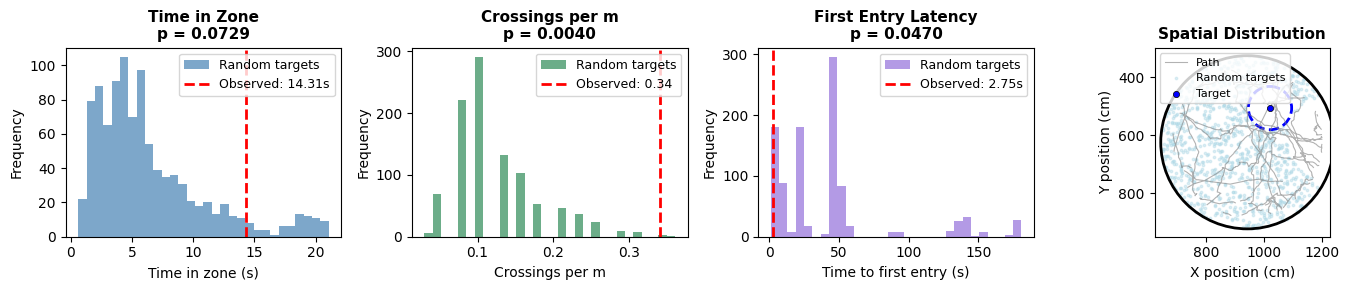

In [42]:
individual_x_trim= individual_x[start_frame:int(start_frame+(t*frame_rate))]
individual_y_trim= individual_y[start_frame:int(start_frame+(t*frame_rate))]
individual_x_filt = individual_x_trim[~np.isnan(individual_x_trim)]        
individual_y_filt = individual_y_trim[~np.isnan(individual_y_trim)]

# ========== Compute Observed metrics  ==========
enter_reward_zone = 0
consecutive_count = 0    
first_entry_latency = len(individual_x_trim)/frame_rate
first_entry_frame_on_filtered = None
time_spent_in_zone = 0
crossings_per_m = 0
for i, (x, y) in enumerate(zip(individual_x_filt, individual_y_filt)):
    if calculate_relative_distance(x, y, reward_x, reward_y) <= reward_zone:
        time_spent_in_zone += 1
        if first_entry_frame_on_filtered is None:
            first_entry_frame_on_filtered = i
        if consecutive_count == 0:
            enter_reward_zone += 1
            consecutive_count = 1
    else:
        consecutive_count = 0  

if first_entry_frame_on_filtered is not None:
    first_entry_frameX = np.where(individual_x == individual_x_filt[int(first_entry_frame_on_filtered)])
    first_entry_frameY = np.where(individual_y == individual_y_filt[int(first_entry_frame_on_filtered)])
    common = np.intersect1d(first_entry_frameX, first_entry_frameY)
    first_entry_frame = int(common[0])
    first_entry_latency = (first_entry_frame - start_frame) / frame_rate
    crossings_per_m = round(enter_reward_zone / (round(total_distance) / 100), 2)
    time_spent_in_zone = time_spent_in_zone / frame_rate

# ========== Compute Permuted metrics  ==========
n_permutations = 1000
np.random.seed(42)

random_time_spent_in_zone = []
random_first_entry_latency = []
random_crossings_per_m = []
random_targets = []

while len(random_time_spent_in_zone) < n_permutations:
    # Generate random location uniformly within circular table
    r = table_radius * np.sqrt(np.random.rand())
    theta = 2 * np.pi * np.random.rand()
    rx = table_center_x + r * np.cos(theta)
    ry = table_center_y + r * np.sin(theta)
    
    # Skip if surrogate overlaps with reward zone (optional exclusion)
    if calculate_relative_distance(rx, ry, reward_x, reward_y) <= reward_zone:
        continue
    # Skip if surrogate overlaps with start zone (optional exclusion)
    if calculate_relative_distance(rx, ry, x_start, y_start) <= start_zone:
        continue

    rand_enter_reward_zone = 0
    consecutive_count = 0    
    rand_first_entry_latency = len(individual_x_trim)/frame_rate
    rand_first_entry_frame_on_filtered = None
    rand_time_spent_in_zone = 0
    rand_crossings_per_m = 0
    for i, (x, y) in enumerate(zip(individual_x_filt, individual_y_filt)):
        if calculate_relative_distance(x, y, rx, ry) <= reward_zone:
            rand_time_spent_in_zone += 1
            if rand_first_entry_frame_on_filtered is None:
                rand_first_entry_frame_on_filtered = i
            if consecutive_count == 0:
                rand_enter_reward_zone += 1
                consecutive_count = 1
        else:
            consecutive_count = 0  
    if rand_first_entry_frame_on_filtered is not None:
        rand_first_entry_frameX = np.where(individual_x == individual_x_filt[int(rand_first_entry_frame_on_filtered)])
        rand_first_entry_frameY = np.where(individual_y == individual_y_filt[int(rand_first_entry_frame_on_filtered)])
        common = np.intersect1d(rand_first_entry_frameX, rand_first_entry_frameY)
        rand_first_entry_frame = int(common[0])
        rand_first_entry_latency = (rand_first_entry_frame - start_frame) / frame_rate
        rand_crossings_per_m = round(rand_enter_reward_zone / (round(total_distance) / 100), 2)
        rand_time_spent_in_zone = rand_time_spent_in_zone / frame_rate

    random_targets.append([rx, ry])
    random_first_entry_latency.append(rand_first_entry_latency)
    random_crossings_per_m.append(rand_crossings_per_m)
    random_time_spent_in_zone.append(rand_time_spent_in_zone)

random_targets = np.array(random_targets)

# ========== CALCULATE P-VALUES ==========
p_value_time_spent_in_zone = (np.sum(random_time_spent_in_zone >= np.array(time_spent_in_zone)) + 1) / (n_permutations + 1)
p_value_crossings_per_m = (np.sum(random_crossings_per_m >= np.array(crossings_per_m)) + 1) / (n_permutations + 1)
p_value_first_entry_latency = (np.sum(random_first_entry_latency <= np.array(first_entry_latency)) + 1) / (n_permutations + 1)


# ========== COMBINED PERFORMANCE METRIC WITH P-VALUE ==========

# Calculate mean and std from random distribution (once)
mean_time_spent_in_zone = np.mean(random_time_spent_in_zone)
std_time_spent_in_zone = np.std(random_time_spent_in_zone)
mean_crossings_per_m = np.mean(random_crossings_per_m)
std_crossings_per_m = np.std(random_crossings_per_m)
mean_first_entry_latency = np.mean(random_first_entry_latency)
std_first_entry_latency = np.std(random_first_entry_latency)

# Calculate z-scores for observed data (relative to random distribution)
z_time_obs = (time_spent_in_zone - mean_time_spent_in_zone) / std_time_spent_in_zone if std_time_spent_in_zone > 0 else 0
z_crossing_obs = (crossings_per_m - mean_crossings_per_m) / std_crossings_per_m if std_crossings_per_m > 0 else 0
z_latency_obs = -(first_entry_latency - mean_first_entry_latency) / std_first_entry_latency if std_first_entry_latency > 0 else 0

observed_perf_3m = z_time_obs + z_crossing_obs + z_latency_obs
observed_perf_2m = z_time_obs + z_crossing_obs 

# Calculate z-scores for each permutation (using SAME mean/std)
z_time_spent_in_zone_perm = (random_time_spent_in_zone - mean_time_spent_in_zone) / std_time_spent_in_zone if std_time_spent_in_zone > 0 else np.zeros_like(random_time_spent_in_zone)
z_crossings_perm = (random_crossings_per_m - mean_crossings_per_m) / std_crossings_per_m if std_crossings_per_m > 0 else np.zeros_like(random_crossings_per_m)
z_latency_perm = -(random_first_entry_latency - mean_first_entry_latency) / std_first_entry_latency if std_first_entry_latency > 0 else np.zeros_like(random_first_entry_latency)

random_perf_3m = z_time_spent_in_zone_perm + z_crossings_perm + z_latency_perm
random_perf_2m = z_time_spent_in_zone_perm + z_crossings_perm

# Calculate p-value
p_value_perf_3m = (np.sum(random_perf_3m >= observed_perf_3m) + 1) / (n_permutations + 1)
p_value_perf_2m = (np.sum(random_perf_2m >= observed_perf_2m) + 1) / (n_permutations + 1)

print(f"On the first {t/60} minutes of the trial:")
print(f"Combined performance p-value (3 metrics): {p_value_perf_3m:.4f}")
print(f"Combined performance p-value (2 metrics): {p_value_perf_2m:.4f}")

# ========== VISUALIZATION ==========
fig, axes = plt.subplots(1, 4, figsize=(14, 3))

# Plot 1: Dwell time distribution
axes[0].hist(random_time_spent_in_zone, bins=30, alpha=0.7, color='steelblue', label='Random targets')
axes[0].axvline(time_spent_in_zone, color='red', linestyle='--', linewidth=2, label=f'Observed: {round(time_spent_in_zone, 2)}s')
axes[0].set_title(f'Time in Zone\np = {p_value_time_spent_in_zone:.4f}', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Time in zone (s)', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].legend(fontsize=9)

# Plot 2: Entry rate distribution
axes[1].hist(random_crossings_per_m, bins=30, alpha=0.7, color='seagreen', label='Random targets')
axes[1].axvline(crossings_per_m, color='red', linestyle='--', linewidth=2, 
                label=f'Observed: {round(crossings_per_m, 2)}')
axes[1].set_title(f'Crossings per m\np = {p_value_crossings_per_m:.4f}', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Crossings per m', fontsize=10)
axes[1].set_ylabel('Frequency', fontsize=10)
axes[1].legend(fontsize=9)

# Plot 3: First entry latency distribution
axes[2].hist(random_first_entry_latency, bins=30, alpha=0.7, color='mediumpurple', label='Random targets')
axes[2].axvline(first_entry_latency, color='red', linestyle='--', linewidth=2, 
                label=f'Observed: {round(first_entry_latency, 2)}s')
axes[2].set_title(f'First Entry Latency\np = {p_value_first_entry_latency:.4f}', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Time to first entry (s)', fontsize=10)
axes[2].set_ylabel('Frequency', fontsize=10)
axes[2].legend(fontsize=9)

# Plot 4: Trajectory and targets
axes[3].plot(individual_x_trim, individual_y_trim, '-', color='gray', alpha=0.6, linewidth=0.8, label='Path')
axes[3].scatter(random_targets[:, 0], random_targets[:, 1], 
                s=3, color='lightblue', alpha=0.4, label=f'Random targets')

# Draw table boundary and target zone
table_circle = plt.Circle([table_center_x, table_center_y], table_radius, fill=False, 
                            color='black', linewidth=2, linestyle='-')
target_circle = plt.Circle([reward_x, reward_y], reward_zone, fill=False, 
                            color='blue', linewidth=2, linestyle='--')
axes[3].add_artist(table_circle)
axes[3].add_artist(target_circle)
axes[3].scatter(*[reward_x, reward_y], color='blue', s=20, 
                zorder=5, edgecolors='black', linewidths=0.5, label='Target')

axes[3].set_aspect('equal')
axes[3].invert_yaxis()
axes[3].set_title('Spatial Distribution', fontsize=11, fontweight='bold')
axes[3].set_xlabel('X position (cm)', fontsize=10)
axes[3].set_ylabel('Y position (cm)', fontsize=10)
axes[3].legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()


Sholl analysis

On the first 2.0 minutes of the trial:


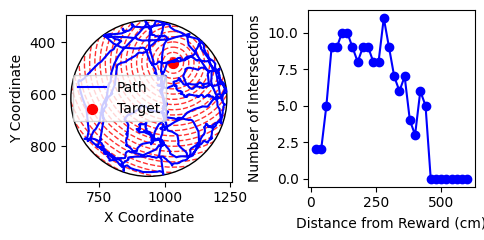

On the first 5.0 minutes of the trial:


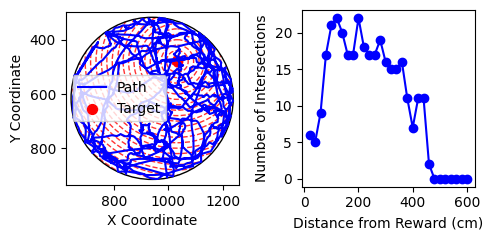

Between 2min and 5min of the trial:


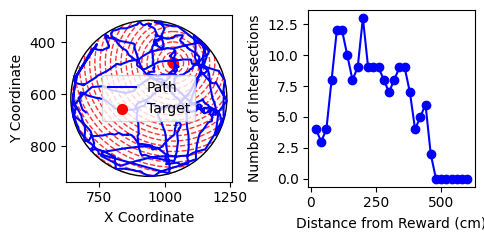

In [9]:
def apply_circular_mask(x, y, x_mask, y_mask, mask_radius):
    path_coords = np.column_stack((x, y))
    mask_center = np.array([x_mask, y_mask])
    dist_to_mask_center = distance.cdist(path_coords, [mask_center]).flatten()
    mask = dist_to_mask_center <= mask_radius
    return x[mask], y[mask]

def sholl_analysis(x, y, xr, yr, x_mask, y_mask, mask_radius=None, max_radius=100, step=10, buffer=20):
    if mask_radius is not None:
        x, y = apply_circular_mask(x, y, x_mask, y_mask, mask_radius)

    path_coords = np.column_stack((x, y))
    target = np.array([xr, yr])
    dist_to_target = distance.cdist(path_coords, [target]).flatten()

    radii = np.arange(step, max_radius + step, step)
    intersections = np.zeros(len(radii), dtype=int)

    for i, radius in enumerate(radii):
        crossings = np.where((dist_to_target[:-1] < radius) & (dist_to_target[1:] >= radius))[0]
        intersections[i] = len(crossings)

    # Plot path and circles

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 2.5))

    ax1.plot(x, y, 'b-', alpha=1, label="Path")
    ax1.scatter(xr, yr, c='red', s=50, label="Target")

    if mask_radius is not None:
        mask_circle = mpath.Path.circle((x_mask, y_mask), radius=mask_radius)
        mask_patch = mpatches.PathPatch(mask_circle, transform=ax1.transData, clip_on=True, facecolor='none', edgecolor='none')

    for radius in radii:
        circle = mpath.Path.circle((xr, yr), radius=radius)
        circle_patch = mpatches.PathPatch(circle, transform=ax1.transData, facecolor='none', edgecolor='r', linestyle='--', alpha=0.8, clip_on=True)
        if mask_radius is not None:
            circle_patch.set_clip_path(mask_patch)
        ax1.add_patch(circle_patch)

    if mask_radius is not None:
        mask_boundary = plt.Circle((x_mask, y_mask), mask_radius, color='black', fill=False, linestyle='-', linewidth=1)
        ax1.add_patch(mask_boundary)
        ax1.set_xlim(x_mask - mask_radius - buffer, x_mask + mask_radius + buffer)
        ax1.set_ylim(y_mask - mask_radius - buffer, y_mask + mask_radius + buffer)

    ax1.set_aspect('equal')
    ax1.invert_yaxis()
    ax1.set_xlabel("X Coordinate")
    ax1.set_ylabel("Y Coordinate")
    ax1.legend()

    # Plot Sholl analysis
    ax2.plot(radii, intersections, 'o-', color='blue')
    ax2.set_xlabel("Distance from Reward (cm)")
    ax2.set_ylabel("Number of Intersections")

    plt.tight_layout()
    plt.show()

    return intersections, radii

t=60*2
print(f"On the first {t/60} minutes of the trial:")
intersections_2min, radii_2min = sholl_analysis(individual_x[start_frame:int(start_frame+(t*frame_rate))], individual_y[start_frame:int(start_frame+(t*frame_rate))], reward_x, reward_y, table_center_x, table_center_y, mask_radius=table_radius, max_radius=table_radius*2, step=20)

t=60*5
print(f"On the first {t/60} minutes of the trial:")
intersections_5min, radii_5min = sholl_analysis(individual_x[start_frame:int(start_frame+(t*frame_rate))], individual_y[start_frame:int(start_frame+(t*frame_rate))], reward_x, reward_y, table_center_x, table_center_y, mask_radius=table_radius, max_radius=table_radius*2, step=20)

t_start = 60 * 2  # 2 minutes
t_end = 60 * 5    # 5 minutes

individual_x2, individual_y2 = interpolate_2d_path(
    individual_x1[t_start:t_end], 
    individual_y1[t_start:t_end], 
    kind='nearest'
)

print(f"Between {t_start//60}min and {t_end//60}min of the trial:")
intersections_5min, radii_5min = sholl_analysis(
    individual_x[int(start_frame + t_start * frame_rate) : int(start_frame + t_end * frame_rate)],
    individual_y[int(start_frame + t_start * frame_rate) : int(start_frame + t_end * frame_rate)],
    reward_x, reward_y, table_center_x, table_center_y,
    mask_radius=table_radius, max_radius=table_radius*2, step=20
)

Plot smoothed heatmap of mouse's path

On the first 5.0 minutes of the trial:


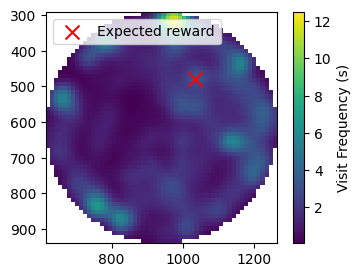

In [12]:
print(f"On the first {t/60} minutes of the trial:")

x_hist = individual_x[start_frame:int(start_frame+(t*frame_rate))]
y_hist = individual_y[start_frame:int(start_frame+(t*frame_rate))]
hist, xedges, yedges = np.histogram2d(x_hist, y_hist, bins=56, range=[[table_center_x - table_radius - table_margin, table_center_x + table_radius + table_margin], [table_center_y - table_radius - table_margin, table_center_y + table_radius + table_margin]])
hist = gaussian_filter(hist, sigma=2)  # Apply Gaussian filter

# Create mask for outside the table circle
x_centers = (xedges[:-1] + xedges[1:]) / 2
y_centers = (yedges[:-1] + yedges[1:]) / 2
X, Y = np.meshgrid(x_centers, y_centers)
distances = np.sqrt((X - table_center_x)**2 + (Y - table_center_y)**2)
mask = distances > table_radius + 5*pixel_to_cm
hist_masked = np.ma.masked_where(mask, hist)

# Plot heat map
fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(hist_masked.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis')#, vmin=0, vmax=10)
#ax.scatter(x_start, y_start, color='black', s=50, label='Start')
ax.scatter(reward_x, reward_y, color='red', s=100, marker='x', label='Expected reward')
ax.set_aspect('equal')
ax.invert_yaxis()
plt.colorbar(im, ax=ax, label='Visit Frequency (s)')
plt.legend(loc='upper left')
plt.show()